In [ ]:
# We read the data and import the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")

df.head()



,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# We extract the midpoint prices from our data.
midpoints = list(df.midpoint)




In [ ]:
# Determine at which indices that the price(midprice) moved.
price_change_indices=[]
for i in range(1,len(midpoints)):
    if midpoints[i-1]!=midpoints[i]:
        price_change_indices.append(i)

    

In [39]:
# We print it.
price_change_indices

[16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 147,
 148,
 149,
 150,
 151,
 152,
 154,
 155,
 156,
 157,
 158,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 192,
 196,
 197,
 198,
 199,
 200,
 202,
 204,
 205,
 206,
 207,
 208,
 209,
 210,
 211,
 212,
 213,
 214,
 215,
 217,
 219,
 221,
 224,
 225,
 226,
 227,
 239,
 240,
 241,
 242,
 243,
 244,
 245,
 246,
 247,
 248,
 249,
 250,
 251,
 252,
 254,
 255,
 256,
 257,
 258,
 259,
 260,

In [42]:
# Determine the inter-arrival times for our data. In our context, "arrival" means price change.
# We will use this for the QQ plot.
inter_arrival_times = []
for i in range(len(price_change_indices)-1):
    inter_arrival_times.append(price_change_indices[i+1]-price_change_indices[i])

inter = np.array(inter_arrival_times)





In [ ]:
# This will be used in determining the parameter of the exponential distribution,
# which will be used in the QQ plot. For more information about QQ plots,visit https://library.virginia.edu/data/articles/understanding-q-q-plots
mu = 1/np.mean(inter)
print(mu)

0.4063903460814913


In [ ]:
# First, turn the inter-arrival-times to a series data type to quantile it easily.
s1 = pd.Series(inter_arrival_times)

# Determine the quantiles. We took 1 million quantiles for our object. 
# One may take even more quantiles for hgiher resolution/precision. 
qs = np.arange(1,1000001,1)
qs = qs/len(qs)
qs = list(qs)






In [43]:
values = s1.quantile(qs)

In [ ]:
# Refer to "quantile_generate.ipynb" 
q_exp = pd.read_csv("exponential_1000000_quantiles.csv")
q_exp = q_exp.drop("Probability",axis=1)
q_exp









,Quantile
0,0.000002
1,0.000005
2,0.000007
3,0.000010
4,0.000012
...,...
999995,30.036847
999996,30.585962
999997,31.293893
999998,32.291666


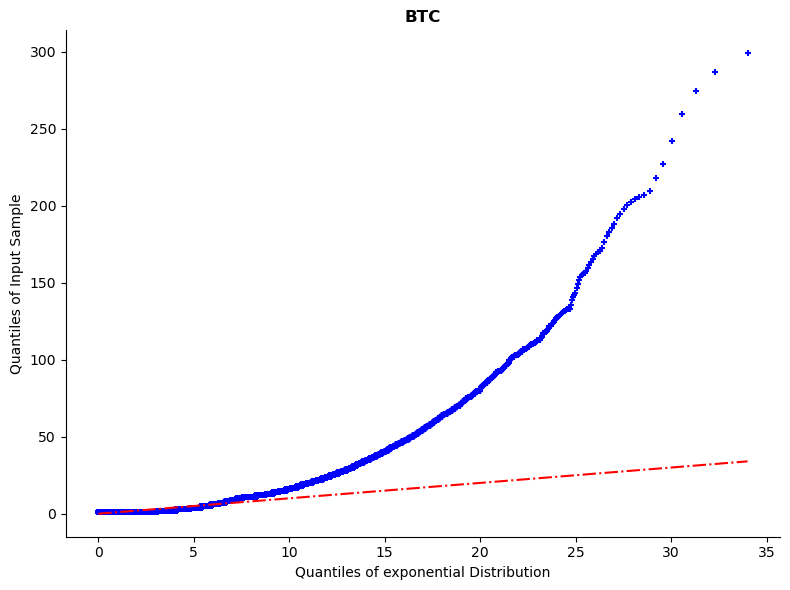

In [54]:
#Plot the QQ plot.
q_exp_list = list(q_exp["Quantile"])
values_list = list(values)
plt.figure(figsize=(8, 6))
plt.scatter(q_exp_list, values_list, marker="+", color="blue", s=20)
plt.plot(q_exp_list, q_exp_list, linestyle='-.', color='red', linewidth=1.5)
plt.xlabel("Quantiles of exponential Distribution")
plt.ylabel("Quantiles of Input Sample")
plt.title("BTC", fontweight='bold')
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
plt.tight_layout()
plt.show()